In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import PIL
import requests
import io
import seaborn as sns

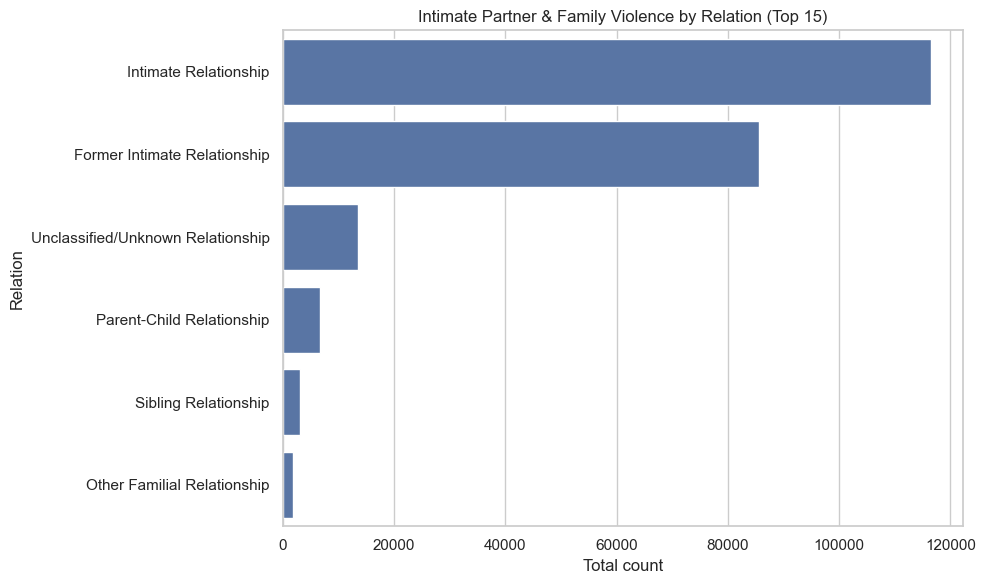

ValueError: Could not interpret value `total` for `y`. An entry with this name does not appear in `data`.

In [ ]:
# 1) Get package + pick a datastore_active resource
base_url = "https://ckan0.cf.opendata.inter.prod-toronto.ca"
package_id = "intimate-partner-and-family-violence"

pkg = requests.get(
    f"{base_url}/api/3/action/package_show",
    params={"id": package_id},
    timeout=60
).json()

resources = pkg["result"]["resources"]
active = [r for r in resources if r.get("datastore_active")]

# choose the first active resource (change index if needed)
resource_id = active[0]["id"]

# 2) Load into pandas
csv_text = requests.get(f"{base_url}/datastore/dump/{resource_id}", timeout=120).text
df = pd.read_csv(io.StringIO(csv_text))

# 3) Aggregate by relation
rel = (
    df.groupby("FAMILY_VIOLENCE_RELATION", dropna=False)["COUNT_"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
      .rename(columns={"COUNT_": "total"})
)

#keep only top N to make the chart readable
top_n = 15
rel_plot = rel.head(top_n)

# 4) Plot
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=rel_plot,
    y="FAMILY_VIOLENCE_RELATION",
    x="total"
)

ax.set_title("Intimate Partner & Family Violence by Relation (Top 15)")
ax.set_xlabel("Total count")
ax.set_ylabel("Relation")

plt.tight_layout()
plt.show()

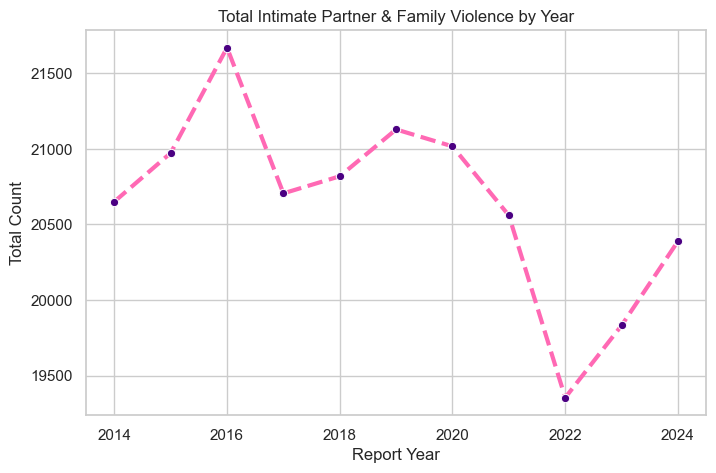

In [37]:
plt.figure(figsize=(8,5))
year_totals = (
    df.groupby("REPORT_YEAR")["COUNT_"]
      .sum()
      .reset_index()
)

yeargraph = sns.lineplot(
    data=year_totals,
    x="REPORT_YEAR",
    y="COUNT_",
    color="hotpink",
    linestyle="--",
    linewidth=3,
    marker="o",
    markerfacecolor="indigo"
)

plt.title("Total Intimate Partner & Family Violence by Year")
plt.xlabel("Report Year")
plt.ylabel("Total Count")

plt.show()


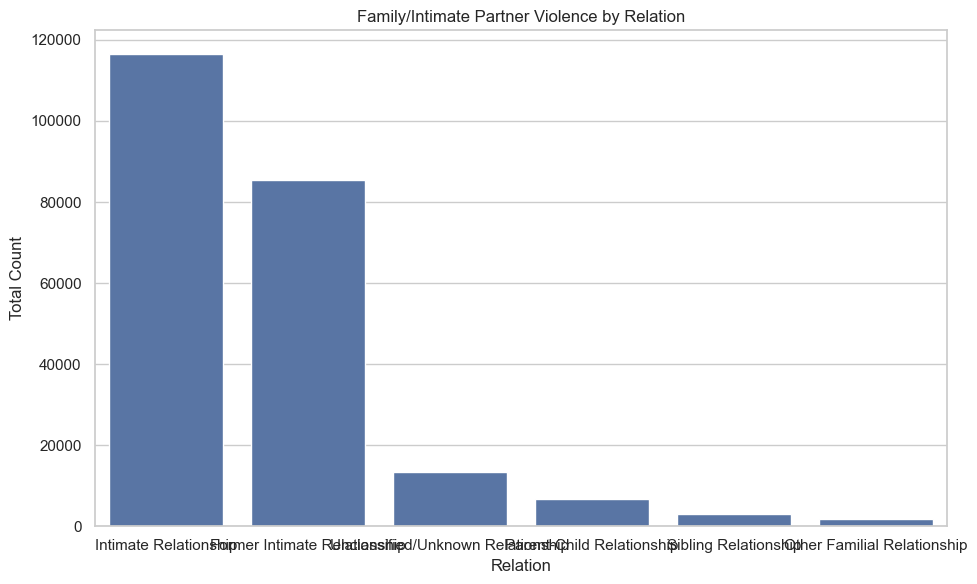

In [23]:
rel = (
    df.groupby("FAMILY_VIOLENCE_RELATION")["COUNT_"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=rel,
    x="FAMILY_VIOLENCE_RELATION",
    y="COUNT_"
)

plt.title("Family/Intimate Partner Violence by Relation")
plt.xlabel("Relation")
plt.ylabel("Total Count")
plt.tight_layout()
plt.show()

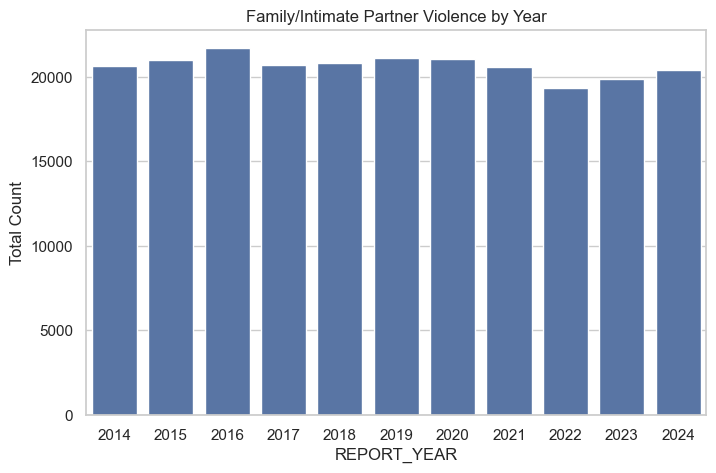

In [20]:
year = (
    df.groupby("REPORT_YEAR")["COUNT_"]
      .sum()
      .reset_index()
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=year,
    x="REPORT_YEAR",
    y="COUNT_"
)

plt.title("Family/Intimate Partner Violence by Year")
plt.ylabel("Total Count")
plt.show()

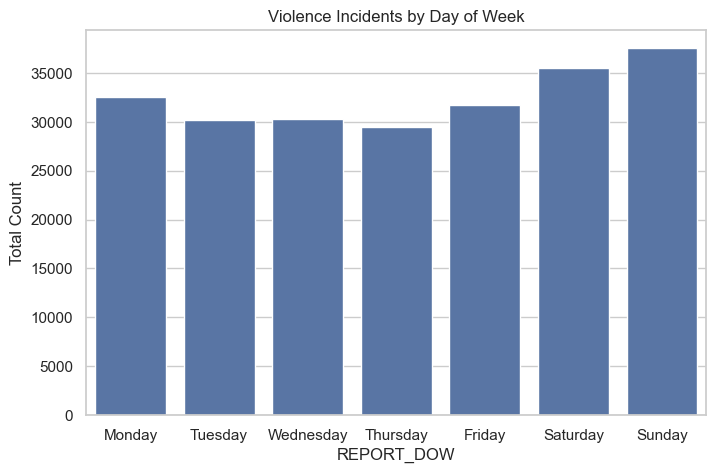

In [ ]:
dow = (
    df.groupby("REPORT_DOW")["COUNT_"]
      .sum()
      .reset_index()
)

# optional: order days properly
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
dow["REPORT_DOW"] = pd.Categorical(dow["REPORT_DOW"], categories=day_order, ordered=True)
dow = dow.sort_values("REPORT_DOW")

plt.figure(figsize=(8,5))

sns.barplot(
    data=dow,
    x="REPORT_DOW",
    y="COUNT_"
)

plt.title("Violence Incidents by Day of Week")
plt.ylabel("Total Count")
plt.show()

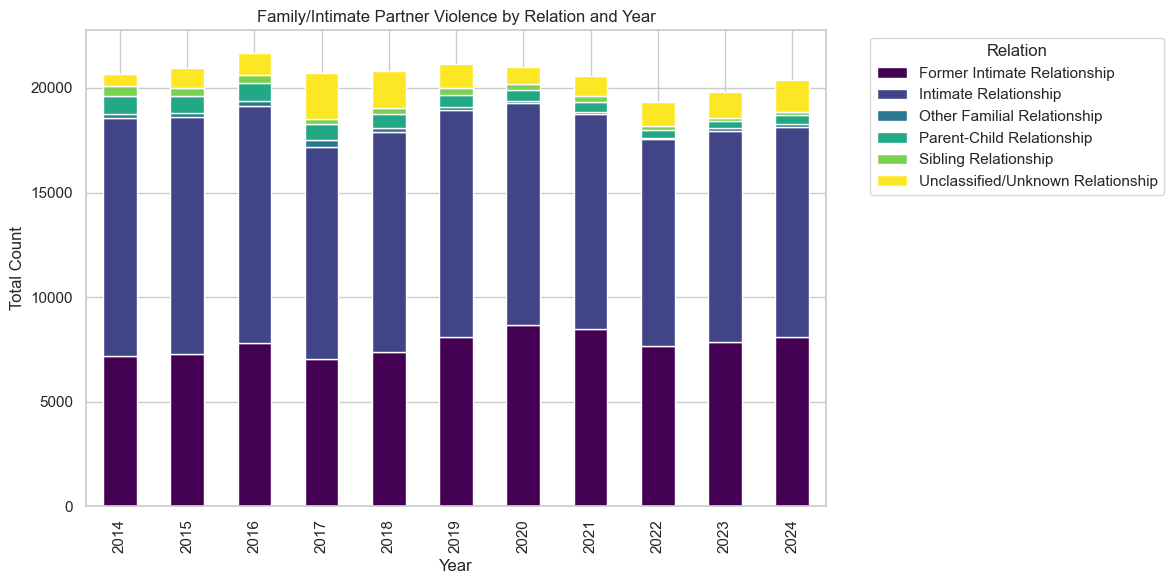

In [26]:
# make sure counts are numeric
df["COUNT_"] = pd.to_numeric(df["COUNT_"], errors="coerce")

# aggregate
rel_year = (
    df.groupby(["REPORT_YEAR","FAMILY_VIOLENCE_RELATION"])["COUNT_"]
      .sum()
      .reset_index()
)

pivot = rel_year.pivot(
    index="REPORT_YEAR",
    columns="FAMILY_VIOLENCE_RELATION",
    values="COUNT_"
).fillna(0)

pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6),
    colormap="viridis"
)

plt.title("Family/Intimate Partner Violence by Relation and Year")
plt.xlabel("Year")
plt.ylabel("Total Count")
plt.legend(title="Relation", bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.show()

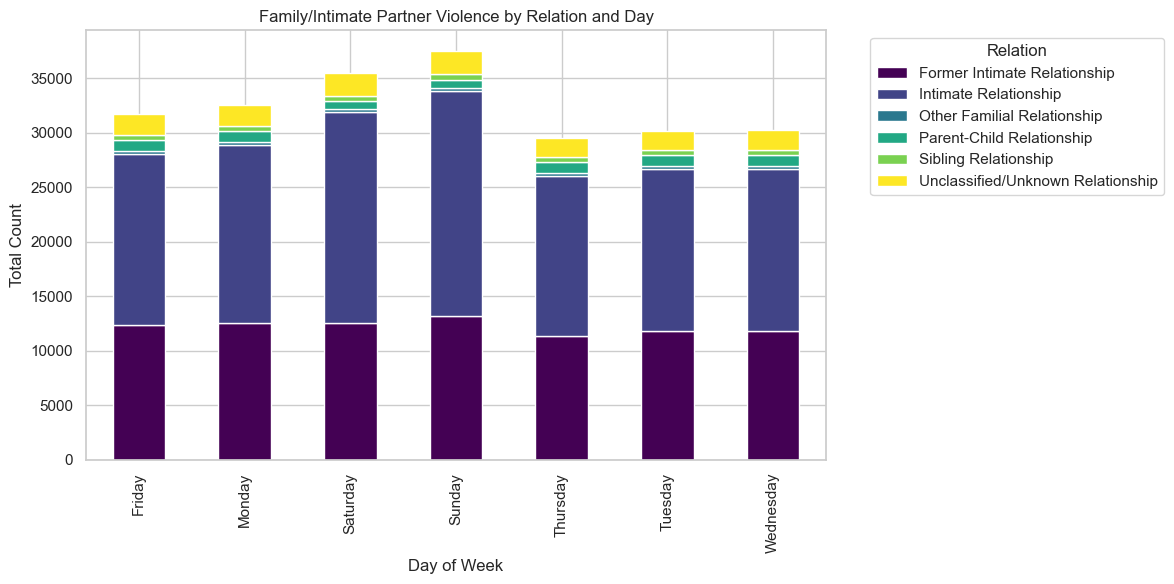

In [27]:
# aggregate
rel_year = (
    df.groupby(["REPORT_DOW","FAMILY_VIOLENCE_RELATION"])["COUNT_"]
      .sum()
      .reset_index()
)

pivot = rel_year.pivot(
    index="REPORT_DOW",
    columns="FAMILY_VIOLENCE_RELATION",
    values="COUNT_"
).fillna(0)

pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6),
    colormap="viridis"
)

plt.title("Family/Intimate Partner Violence by Relation and Day")
plt.xlabel("Day of Week")
plt.ylabel("Total Count")
plt.legend(title="Relation", bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.show()